# Monte Carlo LLM
- Modelling Autoregressive Next Token Prediction as a Search Task through Reinforcement Learning
- Using Llama 3.2 1B on Hugging Face

Steps:
1. Model autoregressive word by word "decode" function which yields a list of "word": prob for top k words
2. Generate a graph for top k words for top 3 choices to visualize
3. Visualize edge weights with various temperatures

- Used for Prof. Iskarous LING 486 NLP Course using the intuition of RLHF as a Reinforcement Learning Search Problem
    - Note: using a probabilistic policy, increasing temperature can help "explore" in the exploration vs. exploitation tradeoff

In [145]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [146]:
tokenizer = AutoTokenizer.from_pretrained(
            "meta-llama/Llama-3.2-1B")
model = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-3.2-1B")

# Uncomment to try different sized models
# tokenizer = AutoTokenizer.from_pretrained(
#             "meta-llama/Meta-Llama-3-8B")
# model = AutoModelForCausalLM.from_pretrained(
#             "meta-llama/Meta-Llama-3-8B")

# tokenizer = AutoTokenizer.from_pretrained(
#             "meta-llama/Llama-3.2-3B")
# model = AutoModelForCausalLM.from_pretrained(
#             "meta-llama/Llama-3.2-3B")

In [ ]:
class DecoderLLM():
    def __init__(self, verbose: bool = True):
        self.tokenizer = tokenizer
        self.model = model
        self.verbose = verbose

    def generate_next_probs(self, prompt: str, num_choices_per_node: int = 2, temperature: float = 1.0) -> list[tuple[str, torch.tensor]]:
        logits = self.generate_next_logits(prompt=prompt)
        prob = self.softmax(logits, temperature=temperature)
        next_word_prob_distr = self.decode_probs(
            prob, top_k=num_choices_per_node)
        return next_word_prob_distr

    def generate_next_logits(self, prompt: str) -> torch.tensor:
        tokenized_input = self.tokenizer(prompt, return_tensors="pt").input_ids

        if (self.verbose):
            print(f"Generating next logits for prompt: {prompt}")
            print(f"\tTokenizing {prompt}: {tokenized_input.shape}")

        with torch.no_grad():
            output = self.model(tokenized_input)

        output_logits = torch.squeeze(output.logits)
        last_logits = output_logits[-1]

        if (self.verbose):
            print(f"\tShape of LLM output: {output_logits.shape}")
            print(f"\tPredicted Logits: {last_logits}")
        return last_logits

    def softmax(self, logits: torch.tensor, temperature: float = 1.0) -> torch.tensor:
        """"
        If temperature is small, peaks are accentuated 
            i.e temperature = 0.1, then softmax([10, 0.1], 0.1) -> [1.0, 0.01]
        If temperature is large, peaks are flattened
            i.e. temperature = 2.0, then softmax([10, 0.1], 2.0) -> [20.0, 0.2] 
        - Follow up with prof. Iskarous on understanding this
        """
        logits = logits / temperature  

        # Center the vector based on max value in order to prevent overflow
        exp_logits = torch.exp(logits - torch.max(logits, dim=-1, keepdim=True).values)
        
        # Apply normalization softmax(x_i) = e^{x_i} / sum_{j=1}^d e^{x_j}
        softmax_probs = exp_logits / torch.sum(exp_logits, dim=-1, keepdim=True)
        
        if self.verbose:
            print(f"Softmax probs: {softmax_probs}")
        
        return softmax_probs


    def decode_probs(self, probs: torch.tensor, top_k: int = 3, bottom_k: int = 0) -> list[tuple[str, torch.tensor]]:
        top_probs, top_idxs = torch.topk(probs, top_k)
        min_probs, min_idxs = torch.topk(-1 * probs, bottom_k)

        output = []
        for prob, idx in zip(top_probs, top_idxs):
            output.append(
                (self.tokenizer.decode(idx), prob)
            )

        # technically this is the bottom 3 reversed but the probabilites are so low it doesn't matter!
        for prob, idx in zip(min_probs, min_idxs):
            output.append(
                (self.tokenizer.decode(idx), -1*prob)
            )
        return output

In [148]:
llm = DecoderLLM(verbose=False)

In [149]:
# Quick Checkpoint making sure the autoregressive code works!
logits = llm.generate_next_logits(prompt="The children went out to")
prob = llm.softmax(logits)

print(f"Santiy check, softmax probs sums to 1.0: {torch.sum(prob)}")

llm.decode_probs(prob, top_k=3, bottom_k=1)

Santiy check, softmax probs sums to 1.0: 1.0000001192092896


[(' play', tensor(0.2767)),
 (' the', tensor(0.2152)),
 (' see', tensor(0.0312)),
 ('之一', tensor(3.5027e-12))]

In [150]:
def create_llm_tree(start_prompt: str, num_choices_per_node: int = 2, max_depth: int = 3, temperature: float = 1.0) -> dict[str, list[tuple[str, float]]]:
    word_tree = {}

    def dfs_helper(prompt: str, cur_depth: int):
        print(f"Depth {cur_depth}: {word_tree}")

        # Base Case) max_depth reached
        if cur_depth == max_depth:
            word_tree[prompt] = []
            return

        # A) Process Current Node
        # Calculate probability distribution
        prob_distr = llm.generate_next_probs(
            prompt,
            num_choices_per_node,
            temperature
        )

        word_tree[prompt] = [
            (prompt+word, prob.item())
            for word, prob in prob_distr
        ]

        # B) Recurse: Process Children
        for next_word, _prob in prob_distr:
            dfs_helper(
                prompt=prompt + next_word,
                cur_depth=cur_depth + 1
            )

    dfs_helper(start_prompt, cur_depth=0)
    return word_tree

In [151]:
# Generated by ChatGPT 4o: "How to visualize a search tree where the probability of each outcome/node is the thickness of the branch edge?"
import networkx as nx
import matplotlib.pyplot as plt

def draw_search_tree(tree, root="root"):
    G = nx.DiGraph()
    pos = {}  # Node positions
    labels = {}  # Node labels
    edge_widths = {}  # Edge thickness (dict for labeling)

    def build_graph(node, depth=0, x=0, width=2.0):
        pos[node] = (x, -depth)
        labels[node] = node
        children = tree.get(node, [])

        if children:
            spread = width / len(children)  # Spread based on the number of children

            for i, (child, prob) in enumerate(children):
                x_child = x + (i - len(children) / 2) * spread  # Distribute children symmetrically
                G.add_edge(node, child)
                edge_widths[(node, child)] = prob
                build_graph(child, depth + 1, x_child, width / 2)  # Reduce width for deeper levels


    build_graph(root)

    plt.figure(figsize=(30, 10))
    edges = G.edges()
    widths = [edge_widths[e] * 5 for e in edges]  # Scale thickness
    nx.draw(G, pos, labels=labels, with_labels=True, node_size=2000, edge_color="black", width=widths, edge_cmap=plt.cm.Blues)

    # Add edge labels
    edge_labels = {e: f"{edge_widths[e]:.2f}" for e in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

    plt.show()

In [152]:
prompt = "What is your "

Depth 0: {}
Depth 1: {'What is your ': [('What is your 201', 0.19475434720516205), ('What is your 3', 0.13830263912677765)]}
Depth 2: {'What is your ': [('What is your 201', 0.19475434720516205), ('What is your 3', 0.13830263912677765)], 'What is your 201': [('What is your 2019', 0.1887025088071823), ('What is your 2018', 0.18436743319034576)]}
Depth 3: {'What is your ': [('What is your 201', 0.19475434720516205), ('What is your 3', 0.13830263912677765)], 'What is your 201': [('What is your 2019', 0.1887025088071823), ('What is your 2018', 0.18436743319034576)], 'What is your 2019': [('What is your 2019 New', 0.1313268095254898), ('What is your 2019 resolution', 0.09111589193344116)]}
Depth 3: {'What is your ': [('What is your 201', 0.19475434720516205), ('What is your 3', 0.13830263912677765)], 'What is your 201': [('What is your 2019', 0.1887025088071823), ('What is your 2018', 0.18436743319034576)], 'What is your 2019': [('What is your 2019 New', 0.1313268095254898), ('What is your 

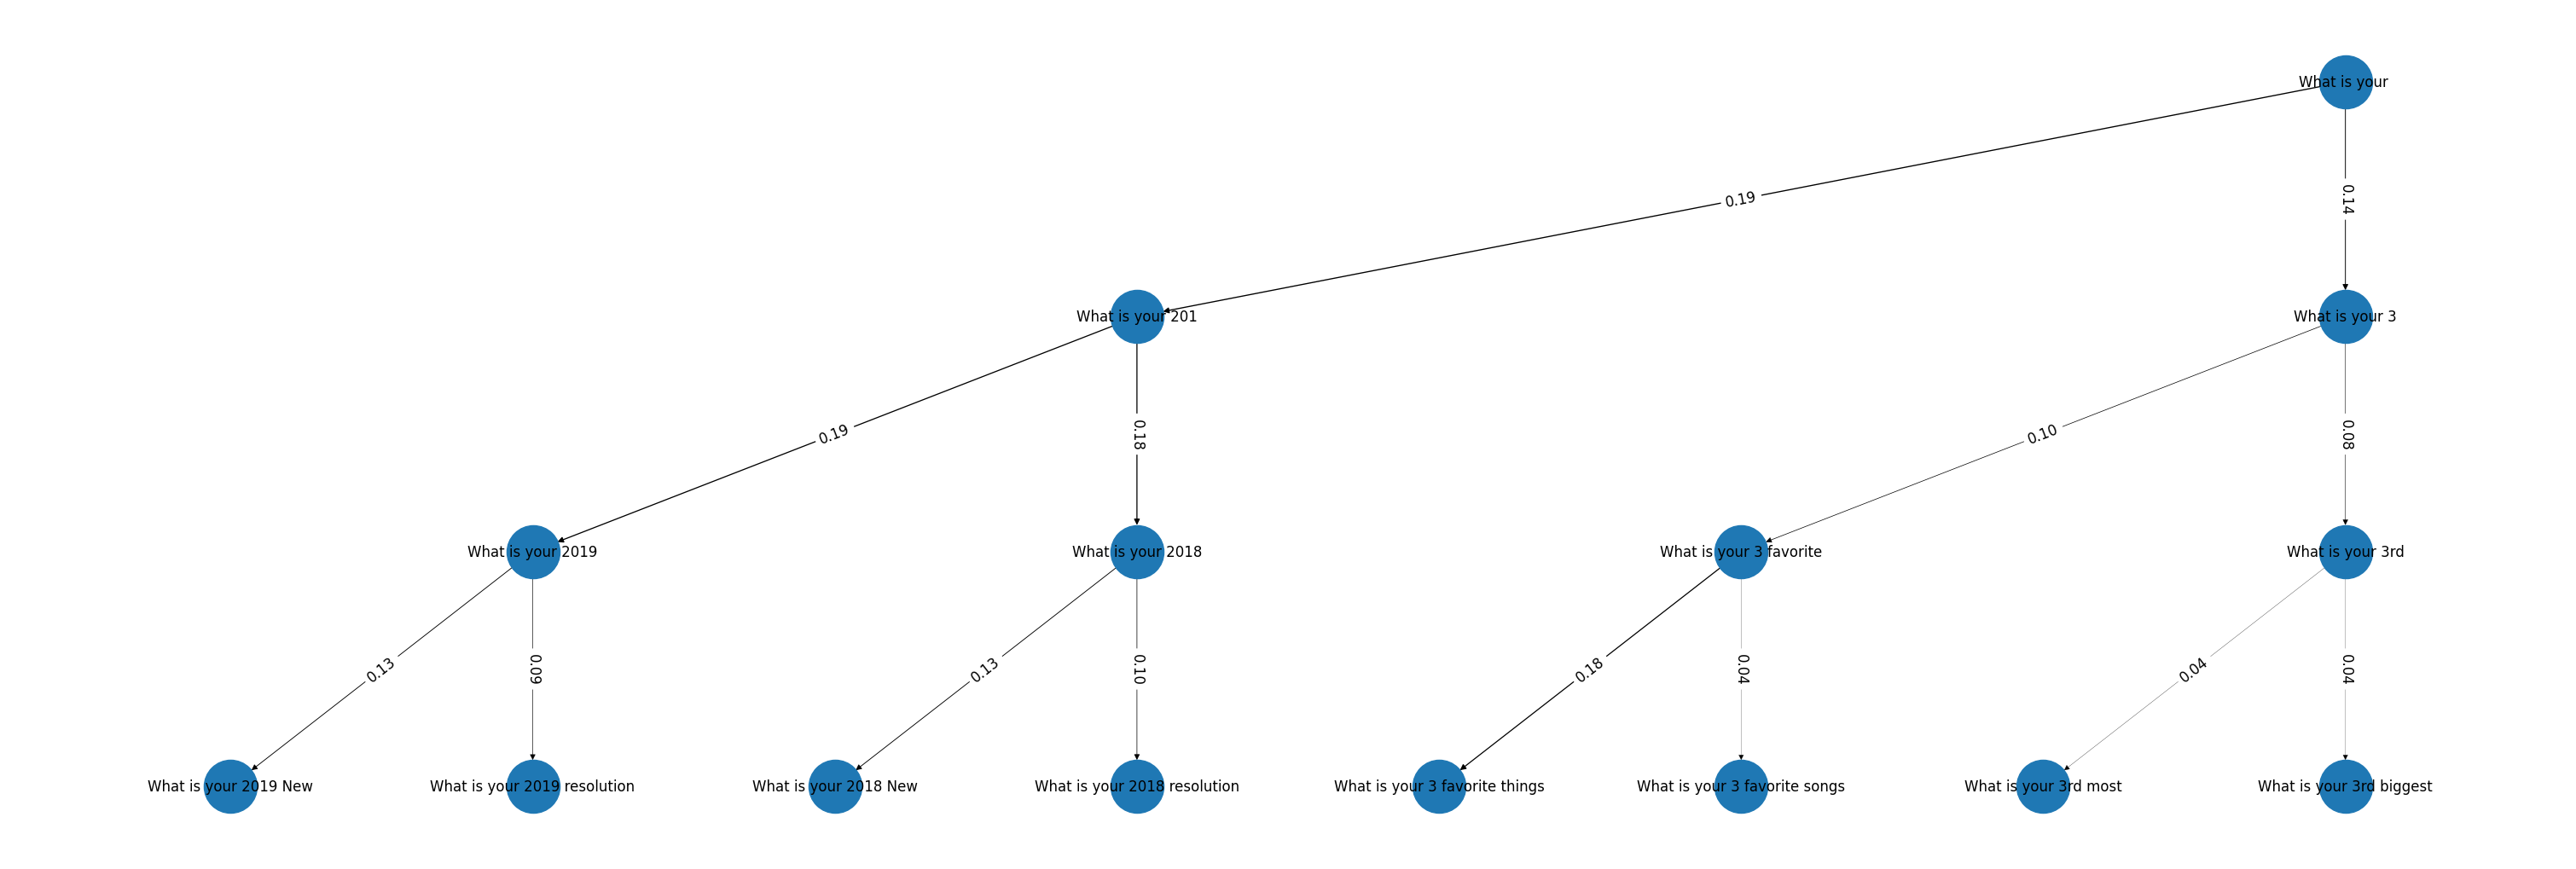

In [153]:
monte_carlo_tree = create_llm_tree(prompt, max_depth=3)
draw_search_tree(monte_carlo_tree, root=prompt)

Depth 0: {}
Depth 1: {'What is your ': [('What is your 201', 0.37471213936805725), ('What is your 3', 0.188966304063797)]}
Depth 2: {'What is your ': [('What is your 201', 0.37471213936805725), ('What is your 3', 0.188966304063797)], 'What is your 201': [('What is your 2019', 0.26651066541671753), ('What is your 2018', 0.2544061839580536)]}
Depth 3: {'What is your ': [('What is your 201', 0.37471213936805725), ('What is your 3', 0.188966304063797)], 'What is your 201': [('What is your 2019', 0.26651066541671753), ('What is your 2018', 0.2544061839580536)], 'What is your 2019': [('What is your 2019 New', 0.5514171719551086), ('What is your 2019 resolution', 0.26543718576431274)]}
Depth 3: {'What is your ': [('What is your 201', 0.37471213936805725), ('What is your 3', 0.188966304063797)], 'What is your 201': [('What is your 2019', 0.26651066541671753), ('What is your 2018', 0.2544061839580536)], 'What is your 2019': [('What is your 2019 New', 0.5514171719551086), ('What is your 2019 res

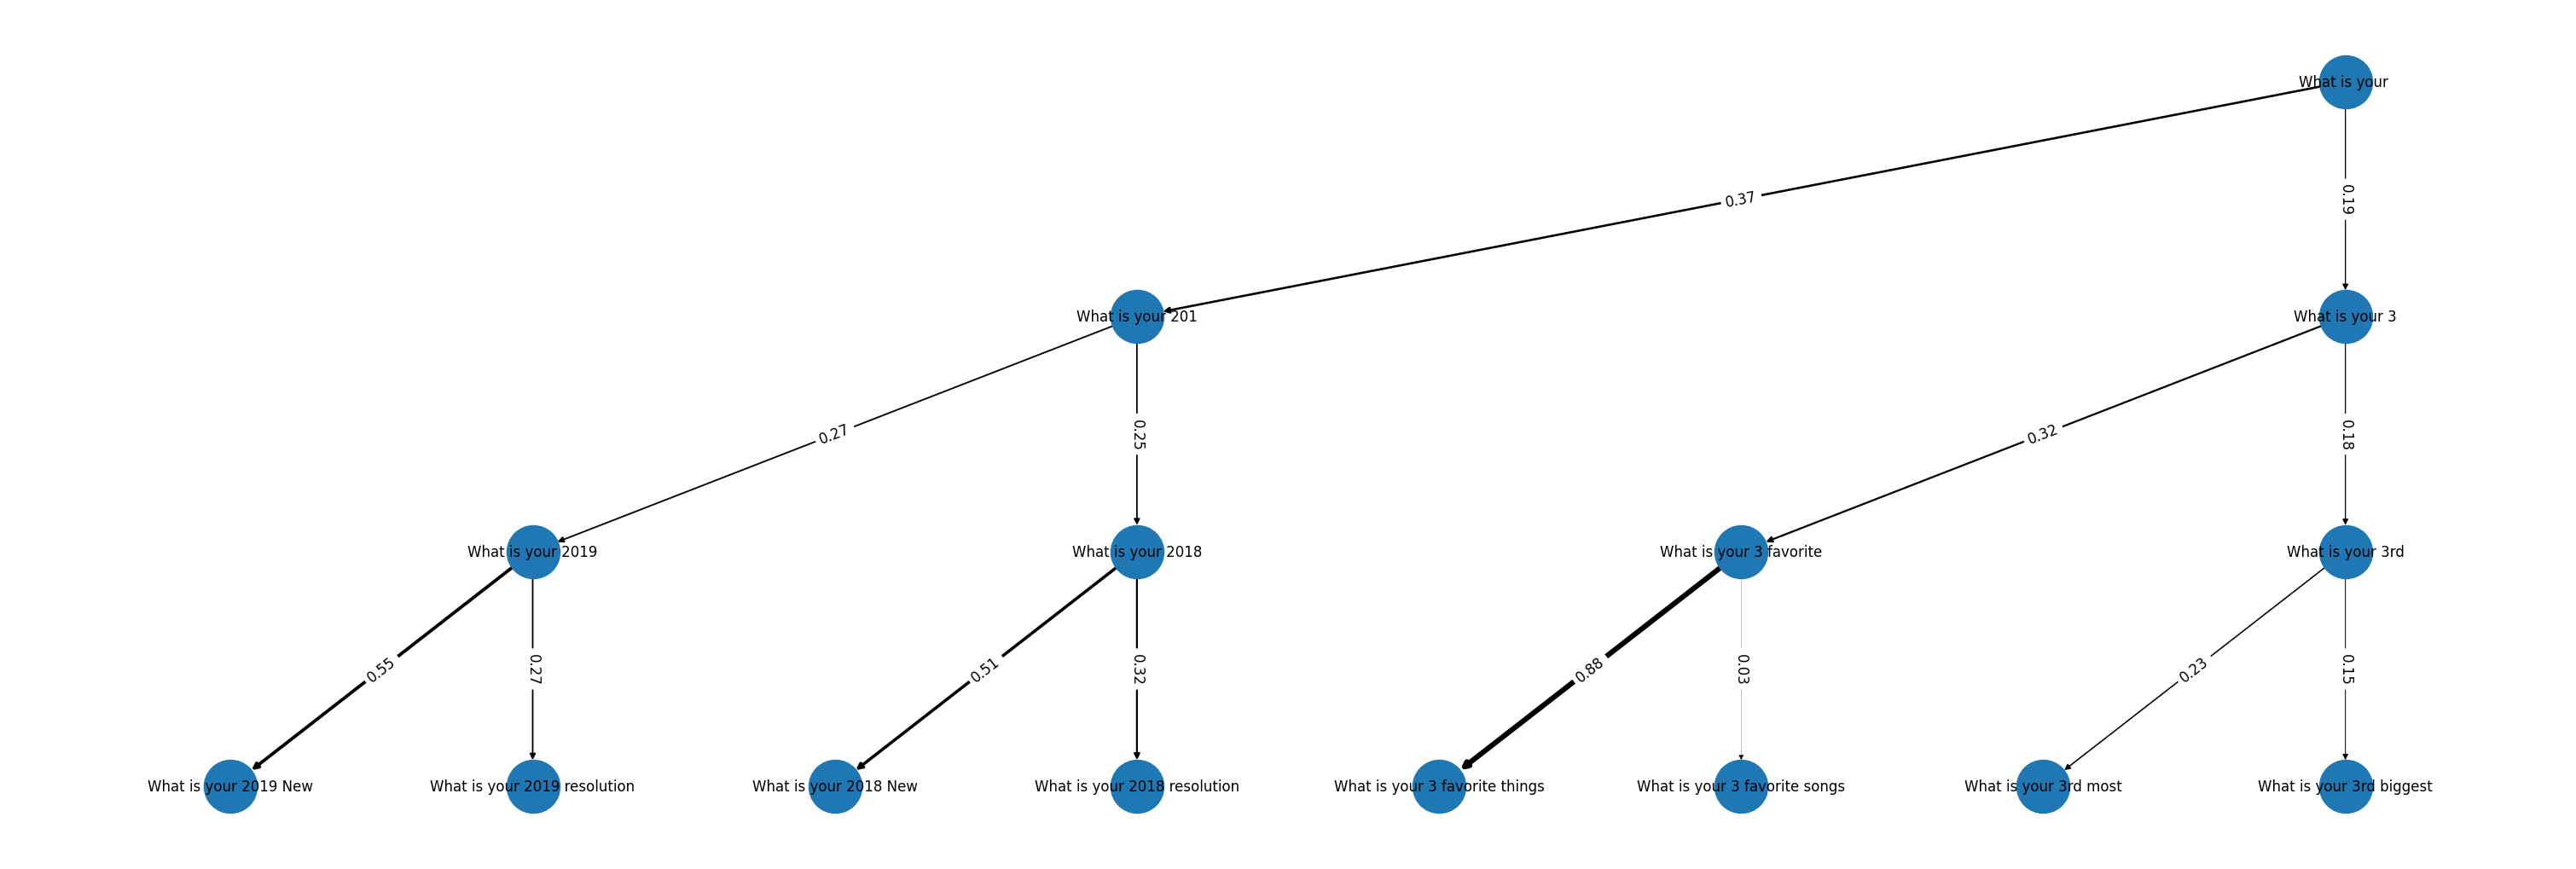

In [154]:
monte_carlo_tree_temp_low = create_llm_tree(prompt, max_depth=3, temperature=0.5)
draw_search_tree(monte_carlo_tree_temp_low, root=prompt)

Depth 0: {}
Depth 1: {'What is your ': [('What is your 201', 0.09288091957569122), ('What is your 3', 0.07393032312393188)]}
Depth 2: {'What is your ': [('What is your 201', 0.09288091957569122), ('What is your 3', 0.07393032312393188)], 'What is your 201': [('What is your 2019', 0.1471821814775467), ('What is your 2018', 0.14491941034793854)]}
Depth 3: {'What is your ': [('What is your 201', 0.09288091957569122), ('What is your 3', 0.07393032312393188)], 'What is your 201': [('What is your 2019', 0.1471821814775467), ('What is your 2018', 0.14491941034793854)], 'What is your 2019': [('What is your 2019 New', 0.020516356453299522), ('What is your 2019 resolution', 0.01607905700802803)]}
Depth 3: {'What is your ': [('What is your 201', 0.09288091957569122), ('What is your 3', 0.07393032312393188)], 'What is your 201': [('What is your 2019', 0.1471821814775467), ('What is your 2018', 0.14491941034793854)], 'What is your 2019': [('What is your 2019 New', 0.020516356453299522), ('What is y

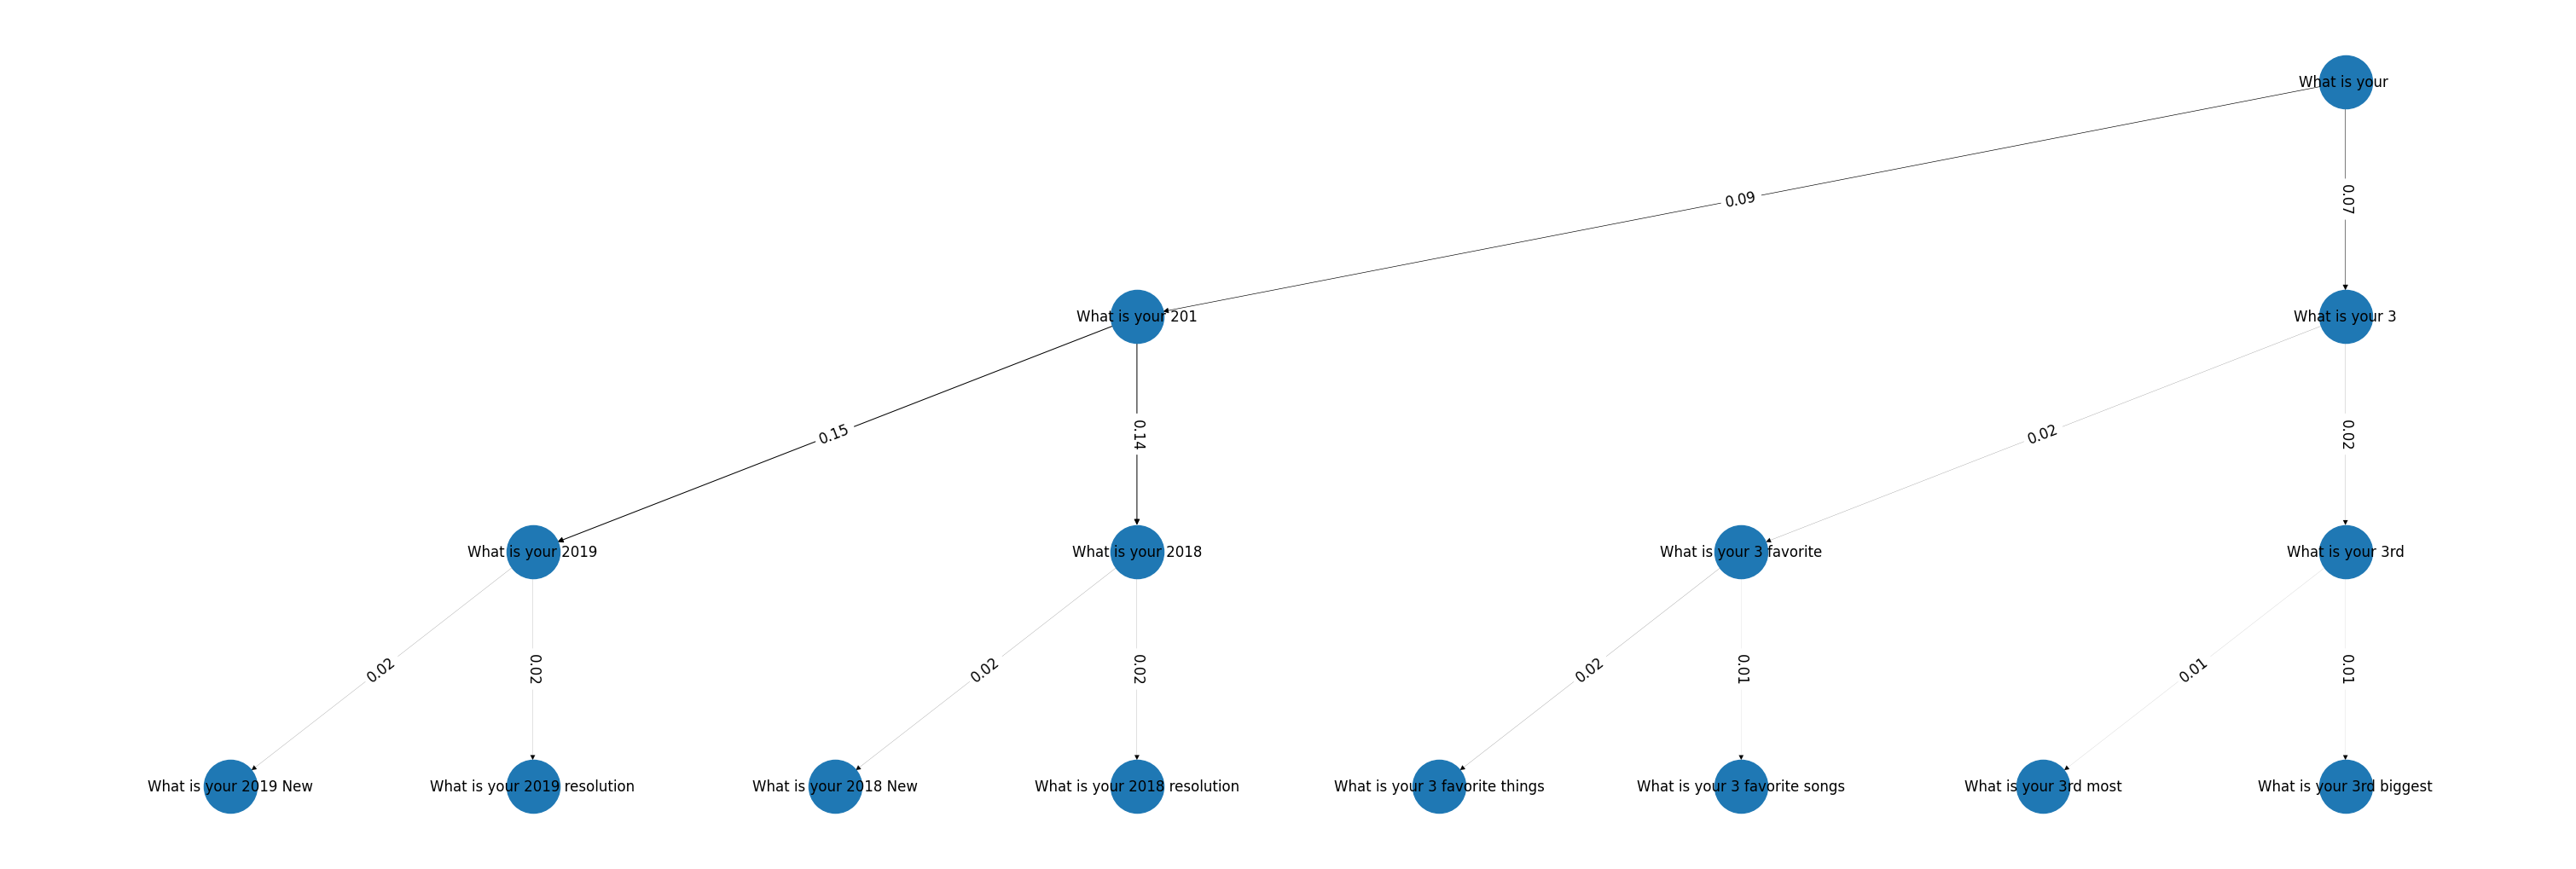

In [155]:
monte_carlo_tree_temp_high = create_llm_tree(prompt, max_depth=3, temperature=1.5)
draw_search_tree(monte_carlo_tree_temp_high, root=prompt)